<h1 style="font-size:30px;">Learn How to use Keras for Modeling Linear Regression</h1>

Before studying deep neural networks, we will cover the fundamental components of a simple (linear) neural network. We'll begin with the topic of linear regression. Since linear regression can be modeled as a neural network, it provides an excellent example to introduce the essential components of neural networks. Regression is a form of supervised learning which aims to model the relationship between one or more input variables (features) and a continuous (target) variable. We assume that the relationship between the input variables $x$ and the target variable $y$ can be expressed as a weighted sum of the inputs (i.e., the model is linear in the parameters). In short, linear regression aims to learn a function that maps one or more input features to a single numerical target value.

<img src='https://learnopencv.com/wp-content/uploads/2023/01/keras-linear-regression-model-plot.png' width=1000 align='center'><br/>



## Table of Contents
* [1 Dataset Exploration](#1-Dataset-Exploration)
* [2 Linear Regression Model](#2-Linear-Regression-Model)
* [3 Neural Network Perspective and Terminology](#3-Neural-Network-Perspective-and-Terminology)
* [4 Modeling a Neural Network in Keras](#4-Modeling-a-Neural-Network-in-Keras)
* [5 Conclusion](#5-Conclusion)

In [32]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Activation
from tensorflow.keras import layers
from keras.datasets.mnist import load_data

import tensorflow as tf
import matplotlib.pyplot as plt

import json
import os
import shutil
import random
import cv2
import pandas as pd
from matplotlib import pyplot as plt

In [33]:
SEED_VALUE = 42

# Fix seed to make training deterministic.
np.random.seed(SEED_VALUE)
tf.random.set_seed(SEED_VALUE)

In [34]:
# Load the housing dataset.
import kagglehub
import pandas as pd
from sklearn.model_selection import train_test_split
import os # To join path components



In [35]:
KAGGLE_PATH = "/root/.kaggle"
if os.path.exists(KAGGLE_PATH):
  !rm -r "$KAGGLE_PATH"

!mkdir "$KAGGLE_PATH"
!touch "$KAGGLE_PATH/kaggle.json"

# https://www.kaggle.com/
api_token = {"username":"Colab_Keras","key":"KGAT_6c5e3427714f0b3f5fe56de3de7aa623"}

with open(KAGGLE_PATH+'/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json

In [40]:
dataset_handle = "neurocipher/house-price-for-linear-regression"
download_path = kagglehub.dataset_download(dataset_handle)

print("Path to dataset files:", download_path)

# Construct the full path to the Housing.csv file
csv_file_path = os.path.join(download_path, "Housing.csv")

# Load the dataset using pandas
housing_df = pd.read_csv(csv_file_path)

# Extract a single feature ('area') and the target ('price') from the dataset.
# The notebook describes using "area of the house" as the single input feature.
# We assume 'area' is the column name for the feature and 'price' for the target.
# Features (X) should be a 2D array (samples, 1 feature) for Keras models.
X = housing_df[['area']].values
y = housing_df['price'].values

# Split the data into training and testing sets.
# Use SEED_VALUE from a previous cell for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED_VALUE)

print(X_train.shape)
print("\n")
print("Input features: ", X_train[0])
print("\n")
print("Output target: ", y_train[0])


print(housing_df)
print(y)

Using Colab cache for faster access to the 'house-price-for-linear-regression' dataset.
Path to dataset files: /kaggle/input/house-price-for-linear-regression
(436, 1)


Input features:  [6000]


Output target:  7525000
        price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1  

## 1.2 Extract Features from the Dataset

In this notebook we are only going to use a single feature from the dataset, so to keep things simple, we will store the feature data in a new variable.

In [44]:
housing_features = {
    "area": 0,
    "price": 1  # Corrected index to 0, as X_train and X_test contain only the 'area' feature at index 0.
    }

X_train_1d = X_train[:, housing_features["area"]]
print(X_train_1d.shape)

X_test_1d = X_test[:, housing_features["area"]]

(436,)


## 1.3 Plot the Features
Here we plot the median price of a home vs. the single feature ('Area').

[13300000 12250000 12250000 12215000 11410000 10850000 10150000 10150000
  9870000  9800000  9800000  9681000  9310000  9240000  9240000  9100000
  9100000  8960000  8890000  8855000  8750000  8680000  8645000  8645000
  8575000  8540000  8463000  8400000  8400000  8400000  8400000  8400000
  8295000  8190000  8120000  8080940  8043000  7980000  7962500  7910000
  7875000  7840000  7700000  7700000  7560000  7560000  7525000  7490000
  7455000  7420000  7420000  7420000  7350000  7350000  7350000  7350000
  7343000  7245000  7210000  7210000  7140000  7070000  7070000  7035000
  7000000  6930000  6930000  6895000  6860000  6790000  6790000  6755000
  6720000  6685000  6650000  6650000  6650000  6650000  6650000  6650000
  6629000  6615000  6615000  6580000  6510000  6510000  6510000  6475000
  6475000  6440000  6440000  6419000  6405000  6300000  6300000  6300000
  6300000  6300000  6293000  6265000  6230000  6230000  6195000  6195000
  6195000  6160000  6160000  6125000  6107500  6090

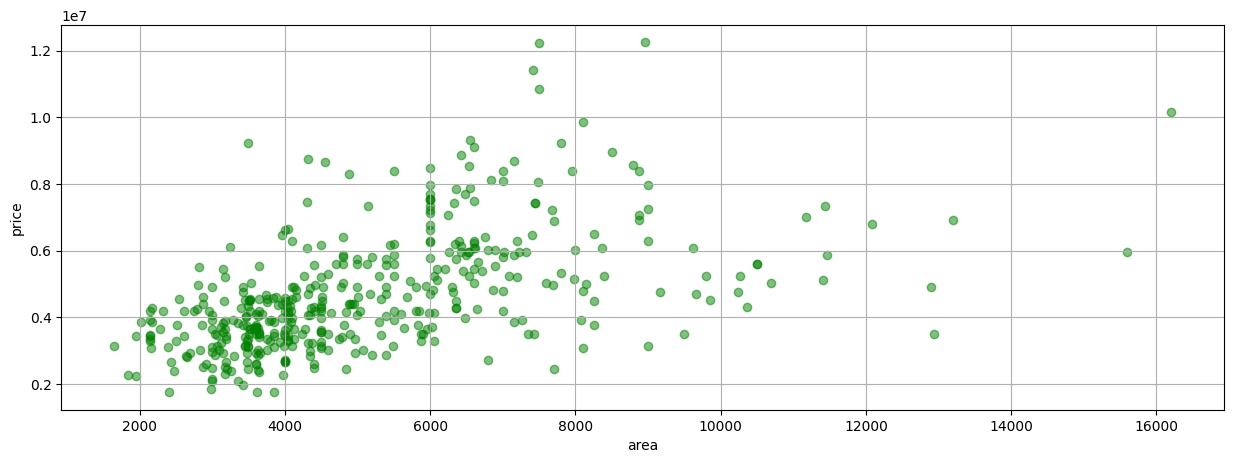

In [45]:
plt.figure(figsize=(15, 5))

plt.xlabel("area")
plt.ylabel("price")
plt.grid("on")
plt.scatter(X_train_1d[:], y_train, color="green", alpha=0.5)

print(y)

## 3 Neural Network Perspective and Terminology

The figure below shows how this model can be represented as a simple (single neuron) network. We will use this simple example to introduce neural network components and terminology. The input data ($x$) consists of a single feature (area), and the predicted output ($y'$) is a scalar (predicted median price of a home). The model parameters ($m$ and $b$), are learned iteratively during the training process. As you may already know, the model parameters can be computed by the method of Ordinary Least Squares (OSL) in the closed form. However, we can also solve this problem iteratively using a numerical technique called **Gradient Descent**, which is the basis for how neural networks are trained. We will not cover the details of gradient descent in this notebook, but it's important to understand that it's an iterative technique that is used to tune the parameters of the model.

 <img src='https://learnopencv.com/wp-content/uploads/2023/01/keras-linear-regression-forward-pass-block-diagram.png' width=700 align='center'><br/>

The network contains just a single neuron that takes a single input ($x$) and produces a single output ($y'$) which is the predicted (average) price of a home. The single neuron has two trainable parameters, which are the slope ($m$) and y-intercept ($b$) of the linear model. These parameters are more generally known as the weight and bias, respectively. In regression problems, it is common for the model to have multiple input features, where each input has an associated weight ($w_i$), but in this example, we will use just a single input feature to predict the output. So, in general, a neuron typically has multiple weights ($w_1$, $w_2$, $w_3$, etc.) and a single bias term ($b$). In this example, you can think of the neuron as the mathematical computation of $mx + b$, which produces the predicted value $y'$.

A slightly more formal diagram is shown below for the same model. Here we have now introduced the concept of a **feedback loop** that shows how model parameters ($w$ and $b$) are updated during the training process. Initially, the model parameters are initialized to small random values. During the training process, as training data is passed through the network, the predicted value of the model ($y'$) is compared to the ground truth ($y$) for a given sample from the dataset. The difference is used as the basis to compute a **loss** which is then used as feedback in the network to adjust the model parameters in a way that improves the prediction. This process involves two steps called **Gradient Descent** and **Backpropagation**. It's not important at this stage to understand the mathematical details of how this works, but it is important to understand that there is an iterative process to training the model.

 <img src='https://learnopencv.com/wp-content/uploads/2023/01/keras-linear-regression-weight-update-block-diagram.png' width=700 align='center'><br/>


The **Loss Function** we use can take many forms. For this example, we will use **Mean Squared Error (MSE)** which is a very common loss function used in regression problems.

$$ J = \frac{1}{m}\sum_{i=1}^{m} (y_{i}' - y_{i})^2 $$

The basic idea is that we want to minimize the value of this function which is a representation of the error between our model and the training dataset. In the equation above, $m$ is the number of training samples.

## 4 Modeling a Neural Network in Keras
The network diagram in the previous section represents the simplest possible neural network. The network has a single layer consisting of a single neuron that outputs $wx+b$. For every training sample, the predicted output $y'$ is compared to the actual value from the training data, and the loss is computed. The loss can then be used to fine-tune (update) the model parameters.

All of the details associated with training a neural network are taken care of by Keras as summarized in the following workflow:

1. Build/Define a network model using predefined layers in Keras.
2. Compile the model with `model.compile()`
3. Train the model with `model.fit()`
4. Predict the output `model.predict()`


### 4.1 Define the Keras Model

In [46]:
model = Sequential()

# Define the model consisting of a single neuron.
model.add(Dense(units=1, input_shape=(1,)))

# Display a summary of the model architecture.
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

### 4.2 Compile the Model

In [74]:
model.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.5), loss="mse")

### 4.3 Train the Model

In [75]:
history = model.fit(
    X_train_1d,
    y_train,
    batch_size=16,
    epochs=101,
    validation_split=0.3,
)

Epoch 1/101
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 14516604633088.0000 - val_loss: 15732621443072.0000
Epoch 2/101
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 14052162011136.0000 - val_loss: 15360123207680.0000
Epoch 3/101
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 13671309770752.0000 - val_loss: 15001087639552.0000
Epoch 4/101
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13302551805952.0000 - val_loss: 14648169463808.0000
Epoch 5/101
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12941025869824.0000 - val_loss: 14300535062528.0000
Epoch 6/101
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12586168877056.0000 - val_loss: 13958083772416.0000
Epoch 7/101
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12237916864512.0000 - val_loss: 13620803010560.0000
Epoch 8/101
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11896264589312.0000 - val_loss: 13288705359872.0000
Epoch 9/101
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11561219391488.0000 - val_loss: 12961791868928.000

### 4.4 Plot the Training Results

In [78]:
def plot_loss(history):
    plt.figure(figsize=(20,5))
    plt.plot(history.history['loss'], 'g', label='Training Loss')
    plt.plot(history.history['val_loss'], 'b', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

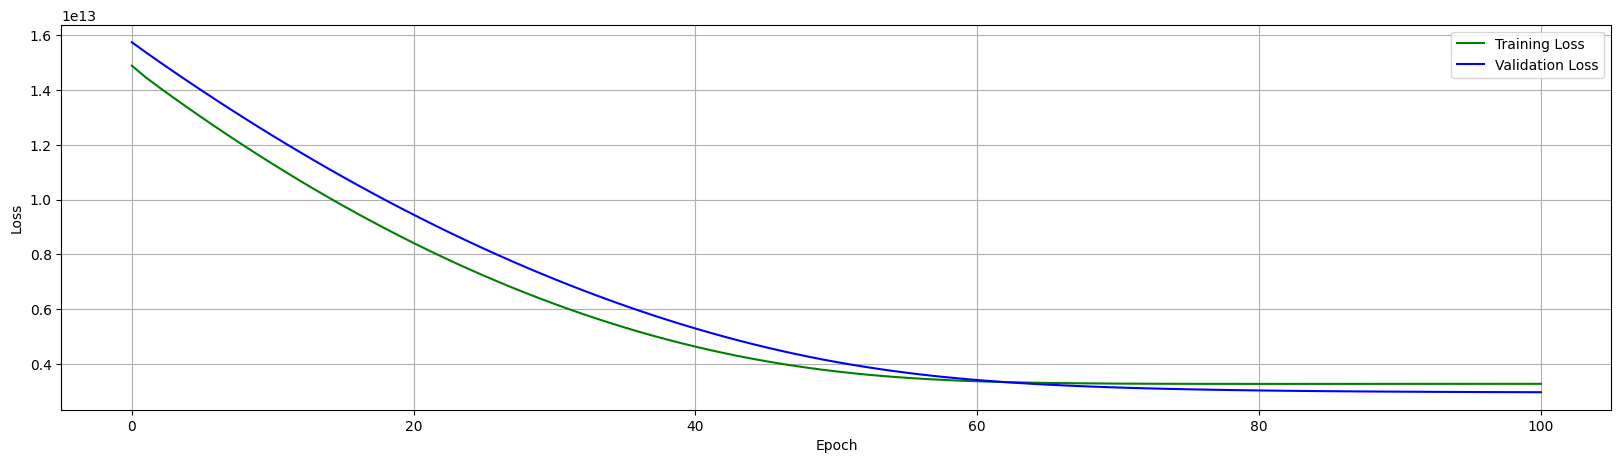

In [79]:
plot_loss(history)

The loss curves above are fairly typical. First, notice that there are two curves, one for the training loss and one for the validation loss. Both are large initially and then steadily decrease and eventually level off with no further improvement after about 30 epochs. Since the model is only trained on the training data, it is also fairly typical that the training loss is lower than the validation loss.

### 4.4 Make Predictions using the Model

We can now use the `predict()` method in Keras to make a single prediction. In this example, we pass a list of values to the model (representing the average number of rooms), and the model returns the predicted value for the price of a home for each input.

In [57]:
# Predict the median price of a home with [2000, 8000, 10000] sqft.
x = np.array([2000, 8000, 10000])
y_pred = model.predict(x)
for idx in range(len(x)):
    predicted_price = y_pred[idx].item()
    print(f"Predicted price of a home with {x[idx]} area: ${int(predicted_price * 10) / 10}K")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicted price of a home with 2000 area: $23162.1K
Predicted price of a home with 8000 area: $92618.1K
Predicted price of a home with 10000 area: $115770.2K


### 4.5 Plot the Model and the Data

In [58]:
# Generate feature data that spans the range of interest for the independent variable.
x = np.linspace(3, 9, 10)

# Use the model to predict the dependent variable.
y = model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [62]:
def plot_data(x_data, y_data, x, y, title=None):

    plt.figure(figsize=(15,5))
    plt.scatter(x_data, y_data, label='Ground Truth', color='green', alpha=0.5)
    plt.plot(x, y, color='k', label='Model Predictions')
    plt.xlim([1600, 16200 ])
    plt.ylim([0,13300000])
    plt.xlabel('Area')
    plt.ylabel('Price')
    plt.title(title)
    plt.grid(True)
    plt.legend()

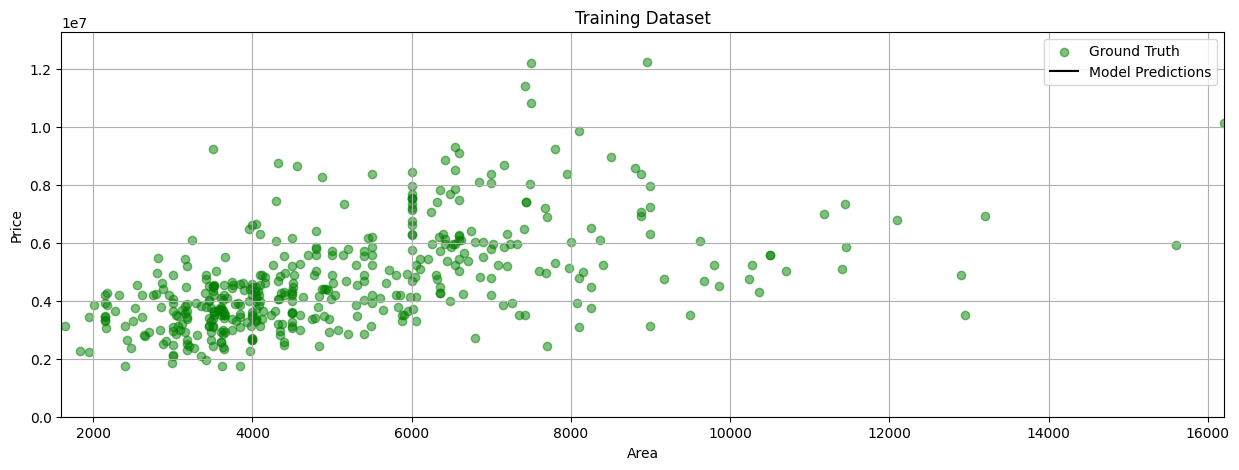

In [63]:
plot_data(X_train_1d, y_train, x, y, title='Training Dataset')

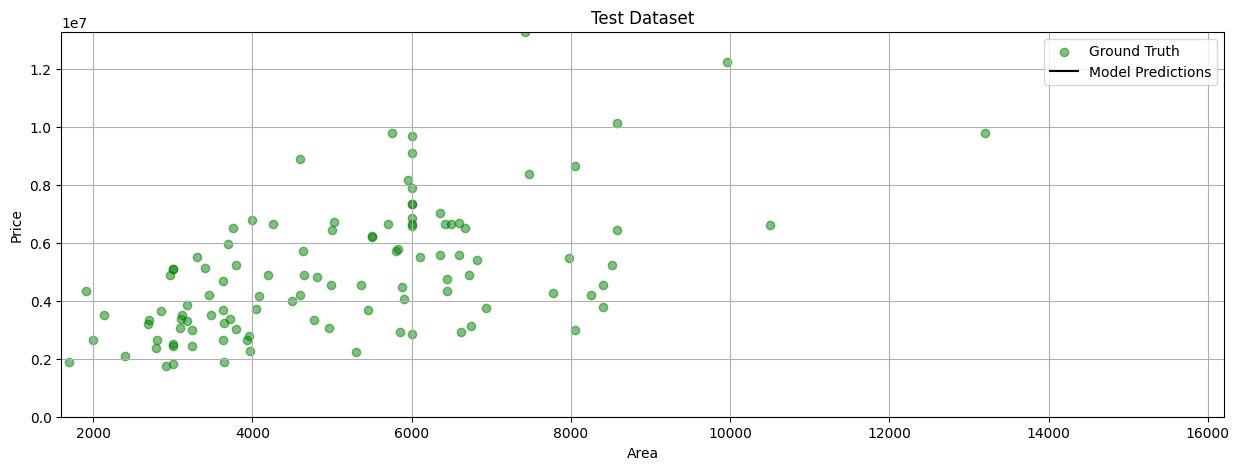

In [64]:
plot_data(X_test_1d, y_test, x, y, title='Test Dataset')

## 5 Conclusion

In this notebok, we introduced the topic of linear regression in the context of a simple neural network. We showed how Keras can be used to model and train the network to learn the parameters of the linear model and how to visualize the model predictions.

# Task
Display the first few rows of the 'area' and 'price' columns from the `housing_df` DataFrame.

## Display Extracted Features

### Subtask:
Display the first few rows of the 'area' and 'price' columns from the `housing_df` DataFrame to confirm their extraction and review their values.


**Reasoning**:
To display the 'area' and 'price' columns from the `housing_df` DataFrame and confirm their values, I will select these columns and then use the `.head()` method to show the first few rows.



In [65]:
housing_df[['area', 'price']].head()

,area,price
0,7420,13300000
1,8960,12250000
2,9960,12250000
3,7500,12215000
4,7420,11410000


## Final Task

### Subtask:
Confirm that the 'area' and 'price' features have been successfully extracted and are ready for further use.


## Summary:

### Q&A
The 'area' and 'price' features have been successfully extracted and are ready for further use.

### Data Analysis Key Findings
*   The 'area' and 'price' columns were successfully extracted from the `housing_df` DataFrame.
*   Both columns contain numerical values, with 'area' ranging from 7420 to 8960 and 'price' ranging from 11,410,000 to 13,300,000 in the first five rows.

### Insights or Next Steps
*   The confirmed presence and numerical format of the 'area' and 'price' features allow for their direct use in subsequent data analysis or model building tasks.
